In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, ttest_ind
from IPython.display import display


class Tele:
    def __init__(self, df=None, filename=None):
        """
        Initialize with either a DataFrame or CSV filename.
        """
        if filename:
            self.df = pd.read_csv(filename)
        elif df is not None:
            self.df = df
        else:
            raise ValueError("Please provide either a DataFrame or a filename.")

    
    def head(self, n=5):
        return self.df.head(n)

    def tail(self, n=5):
        return self.df.tail(n)

    def shape(self):
        return self.df.shape

    def columns(self):
        return self.df.columns.tolist()

    def info(self):
        return self.df.info()

    def describe(self):
        return self.df.describe(include='all')

    def data_types(self):
        return self.df.dtypes

    def unique_counts(self):
        return self.df.nunique()

    def statistics(self):
        return self.df.describe()

    def categorical_summary(self):
        return self.df.describe(include='object')

    def find_null(self):
        return self.df.isnull().sum()

    def null_percentage(self):
        return (self.df.isnull().mean() * 100).round(2)

    def fillna_with_mode(self, col):
        if self.df[col].isnull().sum() > 0:
            mode_val = self.df[col].mode()[0]
            self.df[col].fillna(mode_val, inplace=True)

    def drop_nulls(self):
        self.df.dropna(inplace=True)

    def find_duplicated(self):
        return self.df[self.df.duplicated()]

    def drop_duplicates(self):
        self.df.drop_duplicates(inplace=True)

    def drop_column(self, col):
        self.df.drop(columns=[col], inplace=True)

    def filter_rows(self, condition):
        return self.df.query(condition)

    def convert_dtype(self, col, dtype):
        self.df[col] = self.df[col].astype(dtype)

    def clean_total_charges(self):
        """Special fix for Telecom dataset: convert TotalCharges to numeric."""
        if "TotalCharges" in self.df.columns:
            self.df["TotalCharges"] = pd.to_numeric(self.df["TotalCharges"], errors="coerce")

   
    def detect_outlier(self, column_name):
        if column_name not in self.df.columns:
            raise ValueError(f"{column_name} not found in DataFrame.")
        col = pd.to_numeric(self.df[column_name], errors='coerce').dropna()
        Q1 = col.quantile(0.25)
        Q3 = col.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        mean_val = col.mean()
        print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}, Mean: {mean_val}")
        outliers = self.df[(self.df[column_name] < lower_bound) |
                           (self.df[column_name] > upper_bound)]
        return outliers[column_name].tolist()

    
    def plot_distribution(self, column):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df[column], kde=True)
        plt.title(f"Distribution of {column}")
        plt.show()

    def plot_count(self, column):
        plt.figure(figsize=(8, 4))
        sns.countplot(x=self.df[column])
        plt.title(f"Count Plot of {column}")
        plt.xticks(rotation=45)
        plt.show()

    def box_plots(self, column):
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=self.df[column], color='skyblue')
        plt.title(f'Boxplot of {column}')
        plt.tight_layout()
        plt.show()

    def plot_pie(self, column):
        self.df[column].value_counts().plot.pie(
            autopct="%1.1f%%", figsize=(6, 6), title=f"Pie Chart of {column}")
        plt.ylabel('')
        plt.show()

    def plot_bar(self, column):
        self.df[column].value_counts().plot.bar(figsize=(8, 4), title=f"Bar Chart of {column}")
        plt.xticks(rotation=45)
        plt.show()

    def plot_kde(self, column):
        plt.figure(figsize=(8, 4))
        sns.kdeplot(self.df[column], shade=True)
        plt.title(f"KDE Plot of {column}")
        plt.show()

    def plot_scatter(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=self.df[x], y=self.df[y])
        plt.title(f"Scatter Plot: {x} vs {y}")
        plt.show()

    def plot_line(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=self.df[x], y=self.df[y])
        plt.title(f"Line Plot: {x} vs {y}")
        plt.show()

    def plot_stacked_bar(self, col1, col2):
        pd.crosstab(self.df[col1], self.df[col2]).plot(
            kind="bar", stacked=True, figsize=(10, 6))
        plt.title(f"Stacked Bar Plot: {col1} vs {col2}")
        plt.show()

    def plot_violin(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.violinplot(x=self.df[x], y=self.df[y])
        plt.title(f"Violin Plot: {x} vs {y}")
        plt.show()

    def plot_strip(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.stripplot(x=self.df[x], y=self.df[y], jitter=True)
        plt.title(f"Strip Plot: {x} vs {y}")
        plt.show()

    def plot_swarm(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.swarmplot(x=self.df[x], y=self.df[y])
        plt.title(f"Swarm Plot: {x} vs {y}")
        plt.show()

    def missing_heatmap(self):
        plt.figure(figsize=(10, 6))
        sns.heatmap(self.df.isnull(), cbar=False, cmap="viridis")
        plt.title("Missing Data Heatmap")
        plt.show()

    def correlation_heatmap(self):
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.show()

    
    def chi_square(self, col1, col2):
        table = pd.crosstab(self.df[col1], self.df[col2])
        _, p, _, _ = chi2_contingency(table)
        return p

    def continuous_vs_continuous_correlation(self):
        corr_matrix = self.df.select_dtypes(include=['int64', 'float64']).corr()
        correlated_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                corr_value = corr_matrix.iloc[i, j]
                correlated_pairs.append((col1, col2, corr_value))
        return sorted(correlated_pairs, key=lambda x: abs(x[2]), reverse=True)

    def anova_test(self, target):
        if target not in self.df.columns:
            raise ValueError(f"{target} not found in DataFrame.")

        categorical_cols = self.df.select_dtypes(include='object').columns
        results = []

        for cat in categorical_cols:
            if self.df[cat].nunique() > 1:
                groups = [group[target].dropna().values
                          for _, group in self.df.groupby(cat) if len(group[target].dropna()) > 1]
                if len(groups) > 1:
                    stat, p = f_oneway(*groups)
                    results.append({'Feature': cat, 'ANOVA_p_value': round(p, 4)})
        return pd.DataFrame(results)

    def t_test(self, cat_col, target):
        groups = self.df[cat_col].dropna().unique()
        if len(groups) != 2:
            raise ValueError("T-test is only applicable for binary categorical variables")

        group1 = self.df[self.df[cat_col] == groups[0]][target].dropna()
        group2 = self.df[self.df[cat_col] == groups[1]][target].dropna()
        stat, p = ttest_ind(group1, group2)
        return p

    
    def save_to_csv(self, filename):
        self.df.to_csv(filename, index=False)

    def value_counts(self, col):
        vc = self.df[col].value_counts(dropna=False)
        return pd.DataFrame({"Count": vc, "Percentage": (vc/len(self.df)*100).round(2)})

    def group_summary(self, cat_col, num_col):
        return self.df.groupby(cat_col)[num_col].describe()


In [3]:
Tele_df=Tele(filename="Telco_Customer_churn_Data.csv")

In [4]:
Tele_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
Tele_df.shape()

(7043, 21)

In [6]:
Tele_df.columns()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
Tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
Tele_df.data_types()

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
Tele_df.unique_counts()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [10]:
Tele_df.find_null()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
Tele_df.clean_total_charges()

In [12]:
Tele_df.data_types()

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [13]:
Tele_df.statistics()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
Tele_df.categorical_summary()

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [15]:
Tele_df.value_counts("Churn")

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [16]:
Tele_df.group_summary("Contract", "MonthlyCharges")

,count,mean,std,min,25%,50%,75%,max
Contract,,,,,,,,
Month-to-month,3875.0,66.398490,26.926599,18.75,45.850,73.25,88.875,117.45
One year,1473.0,65.048608,31.840539,18.25,26.900,68.75,94.800,118.60
Two year,1695.0,60.770413,34.678865,18.40,24.025,64.35,90.450,118.75


In [17]:
Tele_df.detect_outlier("MonthlyCharges")

Lower Bound: -46.02499999999999, Upper Bound: 171.375, Mean: 64.76169246059918


[]

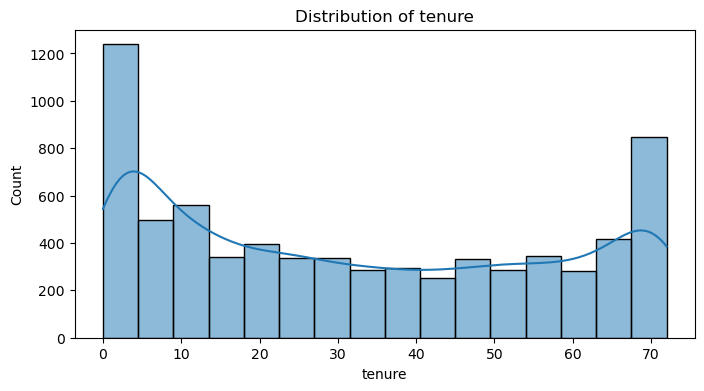

In [18]:
Tele_df.plot_distribution("tenure")

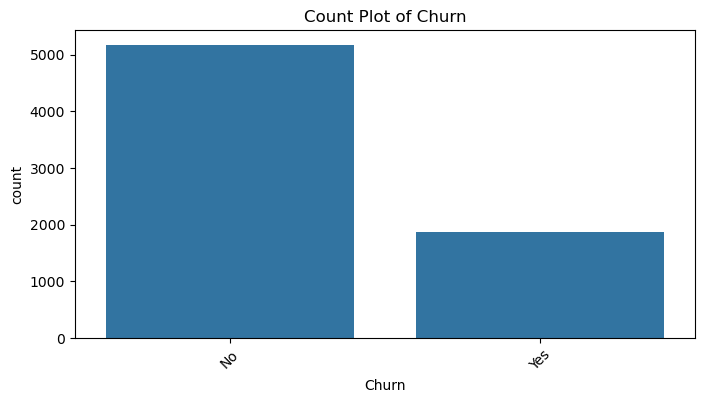

In [19]:
Tele_df.plot_count("Churn")

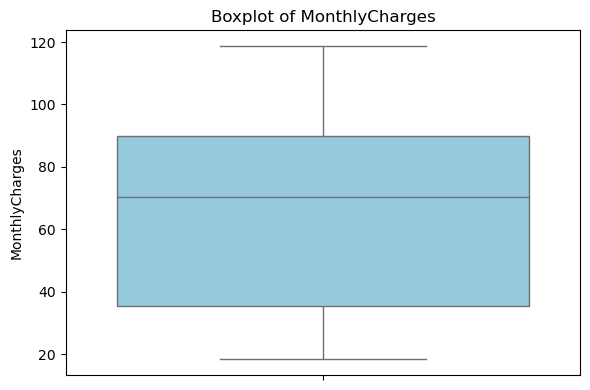

In [20]:
Tele_df.box_plots("MonthlyCharges")

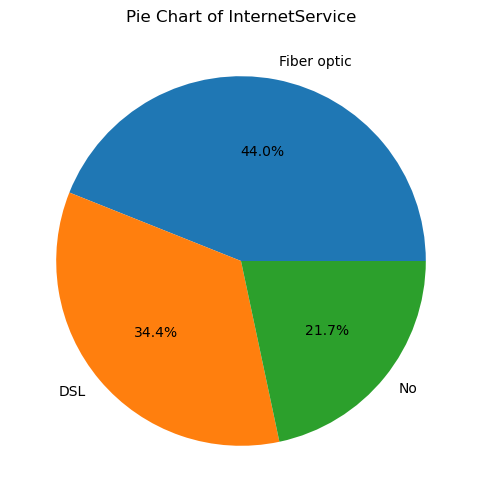

In [21]:
Tele_df.plot_pie("InternetService")

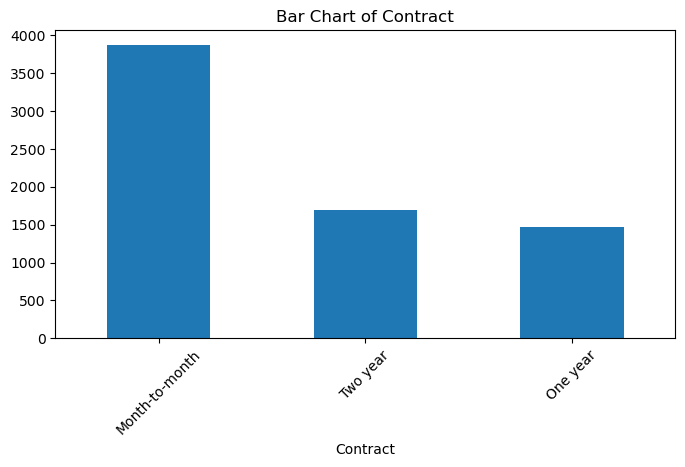

In [22]:
Tele_df.plot_bar("Contract")

C:\Users\HP\AppData\Local\Temp\ipykernel_568\3692643657.py:136: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(self.df[column], shade=True)


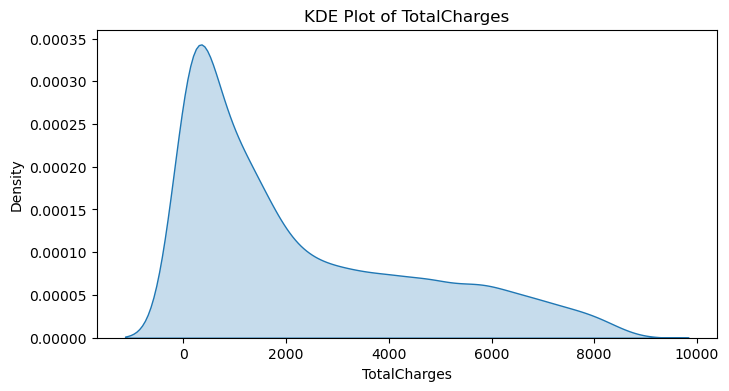

In [23]:
Tele_df.plot_kde("TotalCharges")

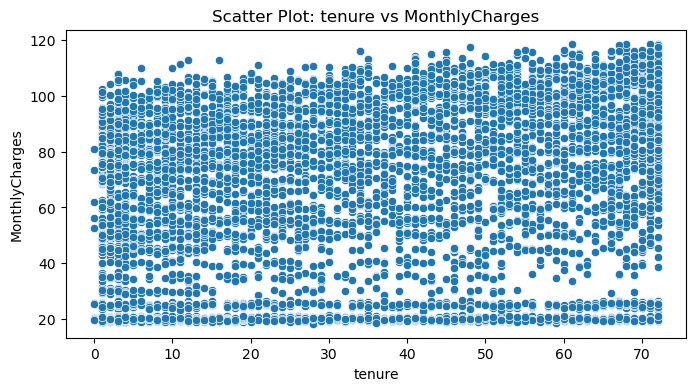

In [24]:
Tele_df.plot_scatter("tenure", "MonthlyCharges")

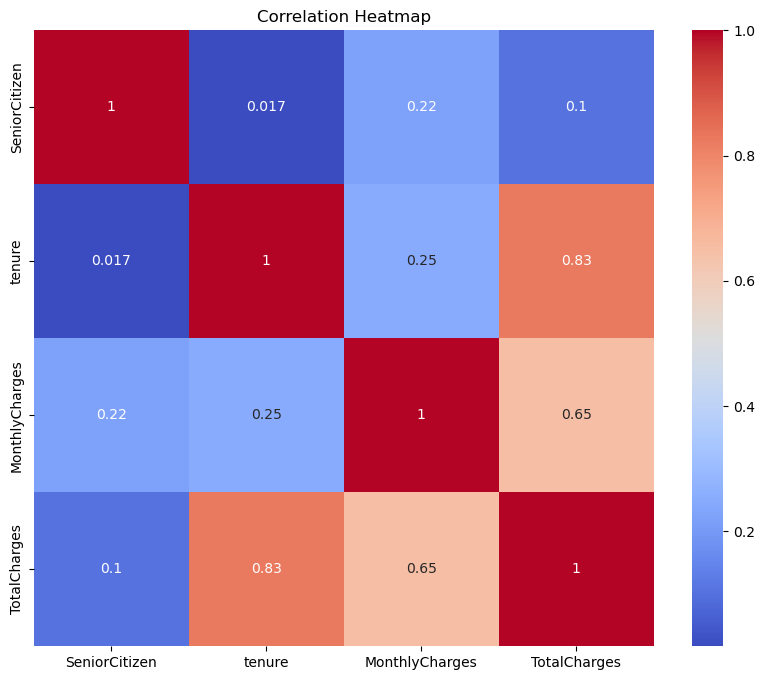

In [25]:
Tele_df.correlation_heatmap()

In [27]:
Tele_df.chi_square("Contract", "Churn")

5.863038300673391e-258

In [28]:
Tele_df.continuous_vs_continuous_correlation()[:5]

[('tenure', 'TotalCharges', 0.8258804609332019),
 ('MonthlyCharges', 'TotalCharges', 0.6510648032262017),
 ('tenure', 'MonthlyCharges', 0.24789985628615094),
 ('SeniorCitizen', 'MonthlyCharges', 0.22017333857627205),
 ('SeniorCitizen', 'TotalCharges', 0.10241060539533069)]

In [29]:
Tele_df.anova_test("MonthlyCharges")

,Feature,ANOVA_p_value
0,gender,0.2215
1,Partner,0.0000
2,Dependents,0.0000
3,PhoneService,0.0000
4,MultipleLines,0.0000
5,InternetService,0.0000
6,OnlineSecurity,0.0000
7,OnlineBackup,0.0000
8,DeviceProtection,0.0000
9,TechSupport,0.0000


In [30]:
Tele_df.t_test("Churn", "MonthlyCharges")

2.7066456068884154e-60